Day 1: Setup, explore dataset, and basic preprocessing

Data Preview:
         lat         lon
0  14.701761  121.021973
1  14.695895  121.013855
2  14.687310  121.001486
3  14.697740  121.011607
4  14.693578  121.001547


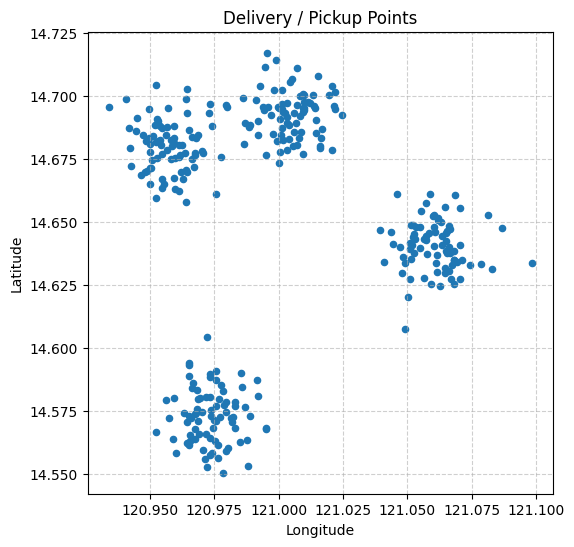

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def make_points(n_centers=4, pts_per_center=80, spread=0.01, seed=42):
    rng = np.random.RandomState(seed)
    centers = rng.uniform(low=[120.95, 14.55], high=[121.1, 14.7], size=(n_centers, 2))  # Manila-ish
    pts = []
    for cx, cy in centers:
        x = rng.normal(cx, spread, pts_per_center)
        y = rng.normal(cy, spread, pts_per_center)
        for xi, yi in zip(x, y):
            pts.append((yi, xi))  # lat, lon
    df = pd.DataFrame(pts, columns=['lat', 'lon'])
    return df

df = make_points()
print("Data Preview:")
print(df.head())

df.to_csv('points.csv', index=False)

df.plot.scatter('lon', 'lat', figsize=(6, 6))
plt.title("Delivery / Pickup Points")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Day 2: K-Means clustering (Euclidean) and choosing k

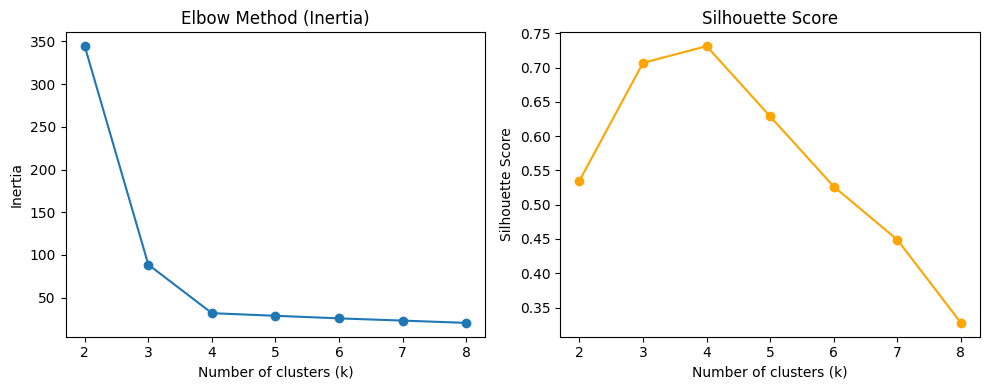

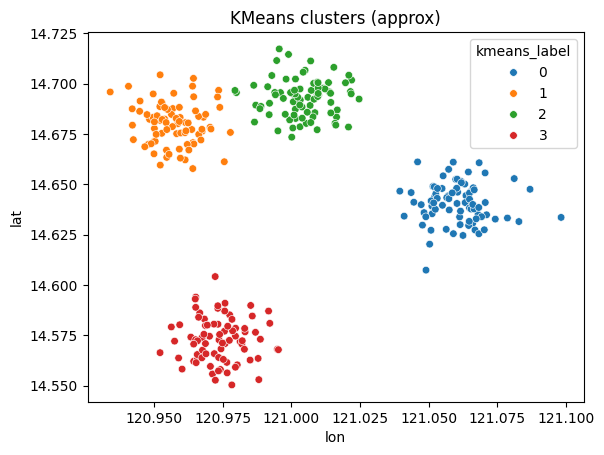

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

def latlon_to_xy(df):
    R = 6371  
    lat0 = np.deg2rad(df['lat'].mean())
    df['x'] = (df['lon'] - df['lon'].mean()) * (np.cos(lat0) * 2 * np.pi * R / 360)
    df['y'] = (df['lat'] - df['lat'].mean()) * (2 * np.pi * R / 360)
    return df

df = latlon_to_xy(df)
X = df[['x', 'y']].values

scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xs, km.labels_))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, '-o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, '-o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
df['kmeans_label'] = km.labels_

sns.scatterplot(data=df, x='lon', y='lat', hue='kmeans_label', palette='tab10', s=30)
plt.title('KMeans clusters (approx)')
plt.show()

df.to_csv('kmeans_assignments.csv', index=False)

DAY 3: DBSCAN for density-based clustering (local proximity / noise)

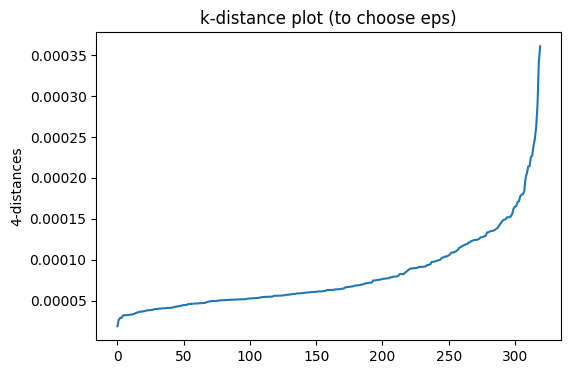

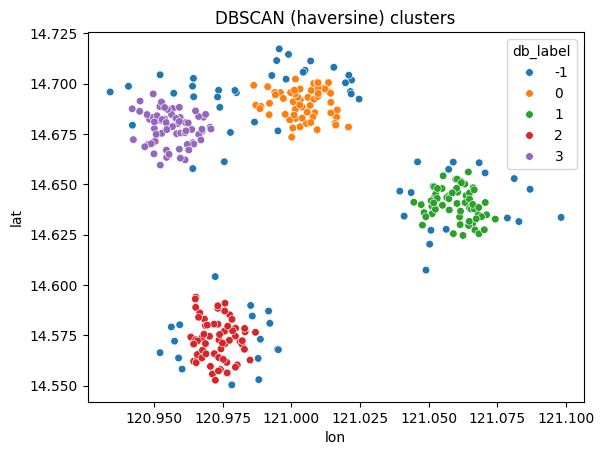

Noise points identified: 20.9%


In [3]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

coords = df[['lat', 'lon']].to_numpy()
coords_rad = np.radians(coords)

k = 4
nbrs = NearestNeighbors(n_neighbors=k).fit(coords_rad)
distances, _ = nbrs.kneighbors(coords_rad)
k_dist = np.sort(distances[:, k-1])

plt.figure(figsize=(6, 4))
plt.plot(k_dist)
plt.ylabel(f'{k}-distances')
plt.title('k-distance plot (to choose eps)')
plt.show()

eps_km = 0.6
eps_rad = eps_km / 6371.0
db = DBSCAN(eps=eps_rad, min_samples=5, metric='haversine').fit(coords_rad)

df['db_label'] = db.labels_

sns.scatterplot(data=df, x='lon', y='lat', hue='db_label', palette='tab10', s=30)
plt.title('DBSCAN (haversine) clusters')
plt.show()

noise_pct = (df['db_label'] == -1).mean() * 100
print(f"Noise points identified: {noise_pct:.1f}%")

df.to_csv('dbscan_assignments.csv', index=False)

DAY 4: Evaluate clusters & use them for proximity optimization

In [4]:
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

print("KMeans silhouette score:", silhouette_score(Xs, df['kmeans_label']))

mask = df['db_label'] != -1
if mask.sum() > 1:
    coords_masked = df.loc[mask, ['x', 'y']].values
    print("DBSCAN silhouette (non-noise):", silhouette_score(coords_masked, df.loc[mask, 'db_label']))

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def cluster_stats(df, label_col):
    stats = []
    for lab, group in df.groupby(label_col):
        if lab == -1: continue
        n = len(group)
        centroid_lat = group['lat'].mean()
        centroid_lon = group['lon'].mean()
        radii = group.apply(lambda r: haversine(r['lat'], r['lon'], centroid_lat, centroid_lon), axis=1)
        stats.append({'cluster': lab, 'count': n, 'centroid_lat': centroid_lat, 
                      'centroid_lon': centroid_lon, 'max_radius_km': radii.max()})
    return pd.DataFrame(stats)

kmeans_summary = cluster_stats(df, 'kmeans_label')
dbscan_summary = cluster_stats(df, 'db_label')

print("\nKMeans Cluster Summary:")
print(kmeans_summary)
print("\nDBSCAN Cluster Summary:")
print(dbscan_summary)

kmeans_summary.to_csv('kmeans_summary.csv', index=False)
dbscan_summary.to_csv('dbscan_summary.csv', index=False)

KMeans silhouette score: 0.7311230986934412
DBSCAN silhouette (non-noise): 0.7791640684395659

KMeans Cluster Summary:
   cluster  count  centroid_lat  centroid_lon  max_radius_km
0        0     80     14.640453    121.060754       4.114028
1        1     79     14.679874    120.957337       3.076053
2        2     81     14.692759    121.004347       2.879950
3        3     80     14.572932    120.973835       3.479639

DBSCAN Cluster Summary:
   cluster  count  centroid_lat  centroid_lon  max_radius_km
0        0     62     14.690209    121.004324       2.205435
1        1     63     14.640196    121.060307       1.855567
2        2     63     14.572889    120.973048       2.496158
3        3     65     14.677978    120.956503       2.100129


DAY 5: Advanced tweaks, map visualization, and export for ops

In [5]:
import folium
from folium.plugins import MarkerCluster

# 1. Create Interactive Folium Map
m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=12)
mc = MarkerCluster().add_to(m)

# Add all points to the map
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3,
        color='red',
        popup=f"id:{_}, k:{row['kmeans_label']}, db:{row['db_label']}"
    ).add_to(mc)

# 2. Add centroids
# Using the kmeans_summary we generated in Day 4
centers = cluster_stats(df, 'kmeans_label')
for _, r in centers.iterrows():
    folium.CircleMarker(
        location=[r['centroid_lat'], r['centroid_lon']],
        radius=7,
        color='blue',
        fill=True,
        fill_color='blue'
    ).add_to(m)

# 3. Save the map
m.save('clusters_map.html')

# 4. Final Export
# Combine the summaries or keep them separate as per your preference
kmeans_summary.to_csv('clusters_summary.csv', index=False)

print("Map saved as 'clusters_map.html'")
print("Summary exported as 'clusters_summary.csv'")

Map saved as 'clusters_map.html'
Summary exported as 'clusters_summary.csv'
